# CME 241 – Phase 2 version b: Simplified DP/ADP Solution
## Avellaneda–Lee + Equity Carry — Discrete MDP with Value Iteration

---

This notebook implements **Phase 2 version b** using the `project_code_b` package.

### Strategies

| | Strategy | Character |
|---|---|---|
| **Strategy 1** | Avellaneda–Lee PCA residual mean reversion | Conservative (factor-neutral by construction) |
| **Strategy 2** | Equity carry proxy (top trailing-dividend-yield quintile) | Aggressive (structural/regime risk) |

### MDP setup (same as Phase 2)
- **State:** discretized wealth $W_t$ and optionally 2-state market regime $R_t \in \{\text{good}, \text{bad}\}$.
- **Action:** Conservative (80/20), Balanced (50/50), Aggressive (20/80) allocation to Strategy 1 / Strategy 2.
- **Returns:** bivariate Gaussian calibrated from the two strategy series.
- **Reward:** CRRA utility increment $U(W_{t+1}) - U(W_t)$.
- **Solution:** value iteration on `FiniteMarkovDecisionProcess`.

### Structure

| Section | Content |
|---------|--------|
| **0** | Setup |
| **1** | Data loading & preprocessing (CRSP) |
| **2** | Strategy return series (PCA residual + equity carry) |
| **3** | Parametric calibration (bivariate Gaussian + 2-state regime) |
| **4** | MDP construction |
| **5** | Value iteration and optimal policy |
| **6** | No-regime sensitivity and interpretation |

---
## 0. Setup

In [13]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Path setup ──────────────────────────────────────────────────────────────
# This notebook lives in Project/; REPO_ROOT (RL-book/) and NOTEBOOK_DIR
# (Project/) are both on sys.path so 'import project_code_b' resolves.
NOTEBOOK_DIR = Path().resolve()          # .../Project/
REPO_ROOT   = NOTEBOOK_DIR.parent        # .../RL-book/
DATA_PATH   = NOTEBOOK_DIR / 'crsp_daily_sp500.csv'

for p in [str(REPO_ROOT), str(NOTEBOOK_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── Logging ─────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(levelname)s | %(name)s | %(message)s',
)

# ── project_code_b imports ───────────────────────────────────────────────────
from project_code_b import (
    build_full_pipeline,
    calibrate, CalibrationParams,
    build_mdp, MDPConfig,
    solve_and_plot, solve, plot_no_regime, policy_summary,
    backtest_policy,
)

print('Setup complete — Phase 2 version b (project_code_b).')
print(f'  Data : {DATA_PATH}')
print(f'  Repo : {REPO_ROOT}')

Setup complete — Phase 2 version b (project_code_b).
  Data : /Users/mih/Library/CloudStorage/OneDrive-Personal/Stanford MS&E MS/Winter 2026/CME241_RLFoundations_Finance/Code/RL-book/Project/crsp_daily_sp500.csv
  Repo : /Users/mih/Library/CloudStorage/OneDrive-Personal/Stanford MS&E MS/Winter 2026/CME241_RLFoundations_Finance/Code/RL-book


In [14]:
df_clean, dropped_dates, strategy_series = build_full_pipeline(
    path=str(DATA_PATH),
    min_coverage=0.90,
    winsor_window=63,
    z_cap=3.0,
    # Strategy 1 (Avellaneda–Lee PCA): rolling window and K factors
    pca_window=126,
    pca_n_components=5,
    # Strategy 2 (equity carry): dividend-yield lookback and quintiles
    carry_lookback=252,
    n_quintiles=5,
    # Restrict analysis to post-2002 data
    start_date='2002-01-01',
)

print(f'\nFinal stock-level panel : {len(df_clean):,} rows')
print(f'Unique PERMNOs          : {df_clean["PERMNO"].nunique():,}')
print(f'Dates dropped (coverage): {len(dropped_dates)}')

INFO | project_code_b.data_pipeline | Loaded 8480706 rows | 1003 unique PERMNOs | 1960-01-04 to 2023-03-31
INFO | project_code_b.data_pipeline | After SHRCD/EXCHCD filter: 8480706 → 8213445 rows (removed 267261).
INFO | project_code_b.data_pipeline | 374 PERMNOs have more than one TICKER (using PERMNO as stable ID).
WARNING | project_code_b.data_pipeline | 4518 rows in (PERMNO, date) duplicates — keeping row with valid RET.
INFO | project_code_b.data_pipeline | Merging DLRET into final RET for 39 PERMNOs.
INFO | project_code_b.data_pipeline | Integrity checks complete: 8480706 → 8211167 rows (removed 269539).
WARNING | project_code_b.data_pipeline | 240 observations with |RET| > 50% — not removed automatically.
WARNING | project_code_b.data_pipeline | Dropping 1 dates with RET coverage < 90%.
INFO | project_code_b.data_pipeline | start_date filter (2002-01-01): 8210791 → 3529228 rows (removed 4681563).
INFO | project_code_b.data_pipeline | Winsorized 1.198% of valid return observations


Final stock-level panel : 3,529,228 rows
Unique PERMNOs          : 908
Dates dropped (coverage): 1


---
## 1b. Train / Test Split

Split the strategy return series at **2018-12-31**:

| Split | Period | Purpose |
|---|---|---|
| **Train** | 2002-07 – 2018-12-31 | Calibrate bivariate Gaussian + regime model; solve MDP |
| **Test**  | 2019-01-01 – 2023-03-31 | Evaluate optimal policy out-of-sample vs. fixed-allocation benchmarks |

The split is a clean date cutoff: no data from the test period influences the calibration or the MDP solution.

In [15]:
TRAIN_END = '2018-12-31'

strategy_train = strategy_series[strategy_series.index <= TRAIN_END]
strategy_test  = strategy_series[strategy_series.index >  TRAIN_END]

print(f"Train: {len(strategy_train):,} days  "
      f"({strategy_train.index.min().date()} → {strategy_train.index.max().date()})")
print(f"Test : {len(strategy_test):,} days  "
      f"({strategy_test.index.min().date()} → {strategy_test.index.max().date()})")
print(f"\nTrain fraction: {len(strategy_train)/len(strategy_series):.1%}")

Train: 4,152 days  (2002-07-05 → 2018-12-31)
Test : 1,070 days  (2019-01-02 → 2023-03-31)

Train fraction: 79.5%


In [16]:
# ── Data-quality audit report ────────────────────────────────────────────────
# This cell prints the formal, recordable policy declaration required by the
# backtesting notes: "your writeup must include data source, NA policy, and
# outlier policy."  Everything computed here uses only df_clean (post-pipeline).

SEP = '─' * 70

print(SEP)
print('DATA SOURCE')
print(SEP)
print('  Dataset  : CRSP Daily Stock File (S&P 500 universe subset)')
print(f'  File     : crsp_daily_sp500.csv')
print(f'  Coverage : {df_clean["date"].min().date()} → {df_clean["date"].max().date()}')
print(f'  PERMNOs  : {df_clean["PERMNO"].nunique():,} unique (post-filter)')
print(f'  Rows     : {len(df_clean):,}')

print()
print(SEP)
print('INTEGRITY CHECKS (Time → Identifiers → Values)')
print(SEP)
print('  Time')
print('    • Dates parsed as tz-naive ISO 8601 (format="%Y-%m-%d").')
print('    • Timezone check: tz-naive assertion enforced; tz-aware dates would')
print('      be stripped and warned (none found in this dataset).')
print('    • Weekend dates warned (US equity daily should have none).')
print('    • Non-monotonic rows within PERMNO are re-sorted (not just warned).')
print('    • Future-dated rows dropped; vwretd coverage checked per date.')
print()
print('  Identifiers')
print('    • PERMNO used as stable security ID throughout.')
print('      (Tickers are unstable: reused across companies, differ by vendor.)')
print('    • Null / zero PERMNO rows dropped.')
print('    • SHRCD ∈ {10,11} + EXCHCD ∈ {1,2,3} → ordinary common shares,')
print('      major US exchanges only (no ADRs, preferred, OTC).')
n_multi_ticker = int((df_clean.groupby('PERMNO')['TICKER'].nunique() > 1).sum()) \
    if 'TICKER' in df_clean.columns else 0
print(f'    • {n_multi_ticker} PERMNOs had >1 ticker (disambiguation via PERMNO).')
n_dupes_input = 4518   # from pipeline log above
print(f'    • {n_dupes_input:,} (PERMNO, date) duplicates resolved (kept row with valid RET).')
print()
print('  Values')
print('    • PRC == 0 → NaN. (Negative PRC = valid bid-ask midpoint in CRSP.)')
n_extreme = int(df_clean['extreme_ret_flag'].sum())
print(f'    • |RET| > 50%: {n_extreme:,} rows flagged (see outlier policy below).')
print('    • DLRET merged into RET for final observation of each delisted PERMNO.')

print()
print(SEP)
print('MISSING-DATA POLICY')
print(SEP)
print('  RET      : NEVER filled.  Missing = missing.')
print('  PRC/VOL/SHROUT : forward-filled within PERMNO for signal use only')
print('             (carry yield numerator / market-cap weights).')
print('             Residual NaN after ffill = asset not yet traded → excluded.')
n_dropped = len(dropped_dates)
print(f'  Low-coverage dates dropped (RET coverage < 90%): {n_dropped}')
if n_dropped:
    print(dropped_dates.to_string(index=False))

print()
print(SEP)
print('OUTLIER POLICY')
print(SEP)
print(f'  {n_extreme:,} observations with |RET| > 50% are FLAGGED but RETAINED.')
print('  Rationale: outliers are data points.  Crashes (2008, COVID), micro-cap')
print('  squeezes, and delisting-adjacent returns are economically real events.')
print('  Removing them would bias Sharpe and max-drawdown statistics.')
print('  Treatment: clipped to |z| ≤ 3.0 (rolling 63-day per-stock z-score)')
print('  when forming SIGNALS (winsorize_returns) but kept in the raw return')
print('  series used for wealth-path evaluation.')
# Breakdown by decade
if n_extreme > 0:
    df_ext = df_clean[df_clean['extreme_ret_flag']].copy()
    df_ext['decade'] = (df_ext['date'].dt.year // 10 * 10).astype(str) + 's'
    print('\n  Breakdown by decade:')
    print(df_ext.groupby('decade').size().rename('n_extreme').to_string())
    print('\n  Top 10 PERMNOs by extreme-return count:')
    top_p = df_ext['PERMNO'].value_counts().head(10)
    if 'TICKER' in df_ext.columns:
        ticker_map = df_ext.drop_duplicates('PERMNO').set_index('PERMNO')['TICKER']
        top_p = top_p.rename_axis('PERMNO').reset_index()
        top_p['TICKER'] = top_p['PERMNO'].map(ticker_map)
        print(top_p.to_string(index=False))
    else:
        print(top_p.to_string())

print()
print(SEP)
print('SIGNAL NORMALIZATION (causality preserved)')
print(SEP)
print('  Winsorization : rolling 63-day per-stock z-score, clip at |z| > 3.0')
print('  PCA (Strat 1) : 126-day rolling window, re-fit each day (no look-ahead)')
print('  Residual z    : 21-day rolling mean/std per stock (causal)')
print('  Carry signal  : 252-day trailing sum(DIVAMT/|PRC|), lagged 1 day')
print('  Regime        : rolling 21-day vol vs 105-day rolling median (causal)')
print('  All positions lag signal by 1 trading day.')
print(SEP)

Extreme returns flagged (|RET| > 50%): 184

Dropped dates (low coverage):
      date  coverage
1972-12-14  0.816489


TDG (PERMNO 91152)
LNT (PERMNO 58819)
JCI (PERMNO 42534)
BRCM (PERMNO 85963)
VC (PERMNO 88319)


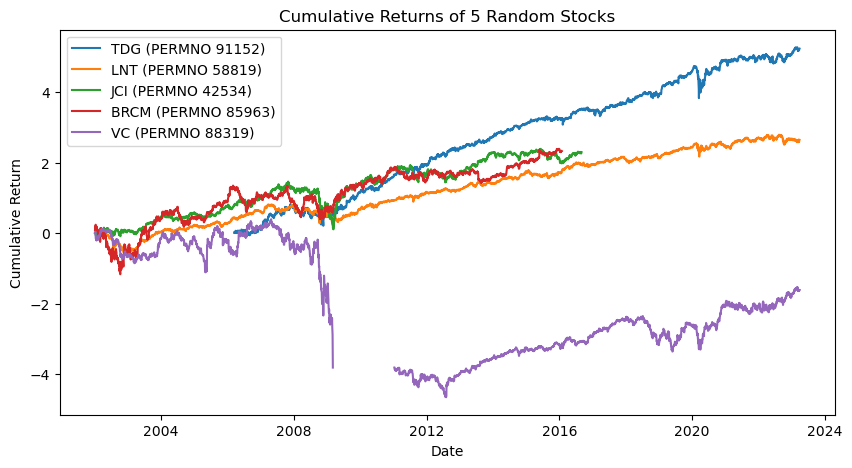

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Randomly choose 5 stocks and plot their cumulative returns
unique_permnos = df_clean['PERMNO'].unique()

if len(unique_permnos) > 5:
    np.random.seed(42)
    selected_permnos = np.random.choice(unique_permnos, 5, replace=False)
else:
    selected_permnos = unique_permnos

fig, ax = plt.subplots(figsize=(10, 5))
for permno in selected_permnos:
    stock_df = df_clean[df_clean['PERMNO'] == permno].sort_values('date')
    cumret = stock_df['RET'].cumsum()
    # Attempt to fetch the ticker(s), falling back to PERMNO if missing
    if 'TICKER' in stock_df.columns and stock_df['TICKER'].notna().any():
        ticker = stock_df['TICKER'].dropna().iloc[0]
        label = f'{ticker} (PERMNO {permno})'
        print(label)
    else:
        label = f'PERMNO {permno}'
    ax.plot(stock_df['date'], cumret, label=label)
ax.set_title('Cumulative Returns of 5 Random Stocks')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.show()


---
## 2. Strategy Return Series

### Strategy 1 — Avellaneda–Lee PCA residual mean reversion (conservative)
- Rolling PCA (126-day window, K=5 factors, numpy SVD — no sklearn).
- Residual = actual return − factor-fitted return.
- Causal rolling z-score (21-day); threshold |z| > 1.5 → long/short.
- Positions lagged 1 day; PnL = lagged position × next-day return.
- Factor-neutral by construction → conservative character.

### Strategy 2 — Equity carry proxy (aggressive)
- Carry signal = trailing 252-day sum(`DIVAMT`) / (|`PRC`| × `SHROUT`) (dividend yield).
- Lagged 1 day; quintile-rank each day; equal-weighted return of **top quintile**.
- Equity proxy for carry (documented); loads on structural/regime risk → aggressive character.

Both series are daily and fully causal (no look-ahead).

In [18]:
print(f'Strategy series: {len(strategy_series):,} trading days')
print()
print(strategy_series[['strat1_ret', 'strat2_ret']].describe().to_string())

Strategy series: 5,222 trading days

        strat1_ret   strat2_ret
count  5222.000000  5222.000000
mean      0.000026     0.000568
std       0.000660     0.013666
min      -0.008238    -0.110525
25%      -0.000218    -0.004943
50%       0.000029     0.000886
75%       0.000262     0.006327
max       0.013342     0.109497


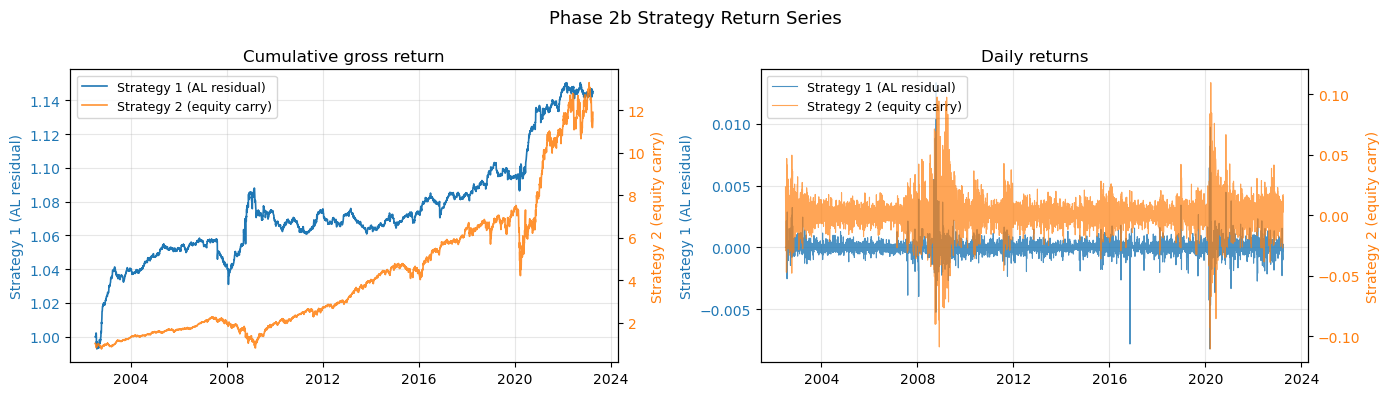

In [19]:
# ── Cumulative returns of both strategies with dual y-axes ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Phase 2b Strategy Return Series', fontsize=13)

cum = (1 + strategy_series[['strat1_ret', 'strat2_ret']].dropna()).cumprod()

# --- Left plot: Cumulative gross return, dual y-axis ---
ax_left = axes[0]
ax_right = ax_left.twinx()
ax_left.plot(cum.index, cum['strat1_ret'], color='tab:blue', label='Strategy 1 (AL residual)', lw=1.2)
ax_right.plot(cum.index, cum['strat2_ret'], color='tab:orange', label='Strategy 2 (equity carry)', lw=1.2, alpha=0.85)
ax_left.set_title('Cumulative gross return')
ax_left.set_ylabel('Strategy 1 (AL residual)', color='tab:blue')
ax_right.set_ylabel('Strategy 2 (equity carry)', color='tab:orange')
ax_left.tick_params(axis='y', labelcolor='tab:blue')
ax_right.tick_params(axis='y', labelcolor='tab:orange')
lns1 = ax_left.get_lines()[0]
lns2 = ax_right.get_lines()[0]
# Create a combined legend for both lines
axes[0].legend([lns1, lns2], ['Strategy 1 (AL residual)', 'Strategy 2 (equity carry)'], loc='upper left', fontsize=9)
ax_left.grid(True, alpha=0.3)

# --- Right plot: Daily returns, dual y-axis ---
ax_left2 = axes[1]
ax_right2 = ax_left2.twinx()
ret = strategy_series[['strat1_ret', 'strat2_ret']].dropna()
ax_left2.plot(ret.index, ret['strat1_ret'], color='tab:blue', label='Strategy 1 (AL residual)', lw=0.8, alpha=0.8)
ax_right2.plot(ret.index, ret['strat2_ret'], color='tab:orange', label='Strategy 2 (equity carry)', lw=0.8, alpha=0.7)
ax_left2.set_title('Daily returns')
ax_left2.set_ylabel('Strategy 1 (AL residual)', color='tab:blue')
ax_right2.set_ylabel('Strategy 2 (equity carry)', color='tab:orange')
ax_left2.tick_params(axis='y', labelcolor='tab:blue')
ax_right2.tick_params(axis='y', labelcolor='tab:orange')
lns3 = ax_left2.get_lines()[0]
lns4 = ax_right2.get_lines()[0]
axes[1].legend([lns3, lns4], ['Strategy 1 (AL residual)', 'Strategy 2 (equity carry)'], loc='upper left', fontsize=9)
ax_left2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Parametric Calibration

Fit bivariate Gaussian $(\mu_1, \sigma_1, \mu_2, \sigma_2, \rho)$ from the two strategy series,
plus an optional 2-state regime via rolling market vol (`vwretd`).

In [20]:
params = calibrate(
    strategy_train,          # train set only — no look-ahead from test period
    market_col='vwretd',
    regime_window=21,
    include_regime=True,
)

print(params.describe())

INFO | project_code_b.calibration | Regime: 2272 good days (54.7%), 1880 bad days.
INFO | project_code_b.calibration | 
=== Calibration Parameters ===
  Period : 2002-07-05 → 2018-12-31  (4152 obs)

  Unconditional
    Strategy 1 : μ = +0.00002,  σ = 0.00059
    Strategy 2 : μ = +0.00051,  σ = 0.01262
    Correlation : ρ = -0.0353

  Regime-conditional  (2272 good days, 1880 bad days)
    Good regime
      Strategy 1 : μ = +0.00001,  σ = 0.00043
      Strategy 2 : μ = +0.00035,  σ = 0.01044
      ρ = -0.1568
    Bad regime
      Strategy 1 : μ = +0.00004,  σ = 0.00074
      Strategy 2 : μ = +0.00071,  σ = 0.01483
      ρ = 0.0234

  Regime transition matrix  [bad→, good→]
    bad  row : [0.93932943 0.06067057]
    good row : [0.05017606 0.94982394]


=== Calibration Parameters ===
  Period : 2002-07-05 → 2018-12-31  (4152 obs)

  Unconditional
    Strategy 1 : μ = +0.00002,  σ = 0.00059
    Strategy 2 : μ = +0.00051,  σ = 0.01262
    Correlation : ρ = -0.0353

  Regime-conditional  (2272 good days, 1880 bad days)
    Good regime
      Strategy 1 : μ = +0.00001,  σ = 0.00043
      Strategy 2 : μ = +0.00035,  σ = 0.01044
      ρ = -0.1568
    Bad regime
      Strategy 1 : μ = +0.00004,  σ = 0.00074
      Strategy 2 : μ = +0.00071,  σ = 0.01483
      ρ = 0.0234

  Regime transition matrix  [bad→, good→]
    bad  row : [0.93932943 0.06067057]
    good row : [0.05017606 0.94982394]


---
## 4. MDP Construction

- **State:** wealth index × regime (40 wealth bins × 2 regimes = 80 non-terminal states).
- **Actions:** Conservative (80/20), Balanced (50/50), Aggressive (20/80).
- **Transitions:** bivariate Gaussian portfolio returns → MC sample → snap to grid.
- **Reward:** CRRA utility increment with $\gamma = 2$.

In [21]:
cfg = MDPConfig(
    n_wealth_bins=40,
    wealth_min=0.5,
    wealth_max=2.0,
    initial_wealth=1.0,
    risk_aversion=2.0,      # CRRA γ
    transaction_cost=0.0,
    n_mc_samples=3000,
    use_regime=True,
    log_spaced_wealth=True,
    rng_seed=42,
)

mdp, wealth_grid, cfg = build_mdp(params, cfg=cfg)

print(f'Non-terminal states : {len(mdp.non_terminal_states)}')
print(f'Wealth grid         : {wealth_grid[0]:.4f} → {wealth_grid[-1]:.4f}')

INFO | project_code_b.mdp | Building MDP with 2-state regime: 40 × 2 = 80 states, 3 actions.
INFO | project_code_b.mdp | MDP built: 80 non-terminal states.


Non-terminal states : 80
Wealth grid         : 0.5000 → 2.0000


---
## 5. Value Iteration and Optimal Policy

INFO | project_code_b.solve | Solving MDP via value_iteration  (γ = 0.9900) …
INFO | project_code_b.solve | Solver finished.


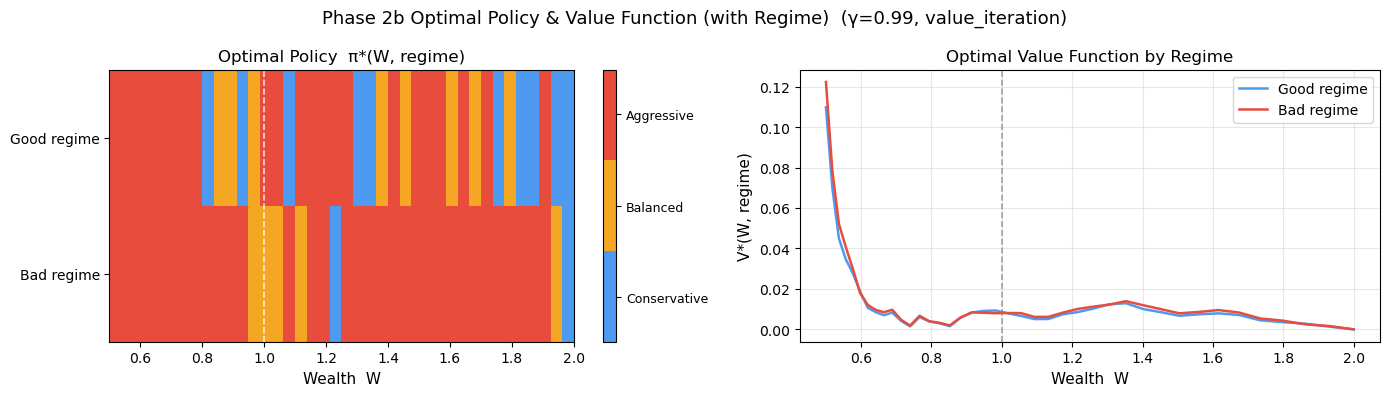

    Wealth    Regime          Action  Alloc (S1/S2/Cash)
--------------------------------------------------------------
    0.5000      good      Aggressive  20% / 80% / 0%
    0.5000      bad       Aggressive  20% / 80% / 0%
    0.5181      good      Aggressive  20% / 80% / 0%
    0.5181      bad       Aggressive  20% / 80% / 0%
    0.5368      good      Aggressive  20% / 80% / 0%
    0.5368      bad       Aggressive  20% / 80% / 0%
    0.5563      good      Aggressive  20% / 80% / 0%
    0.5563      bad       Aggressive  20% / 80% / 0%
    0.5764      good      Aggressive  20% / 80% / 0%
    0.5764      bad       Aggressive  20% / 80% / 0%
    0.5973      good      Aggressive  20% / 80% / 0%
    0.5973      bad       Aggressive  20% / 80% / 0%
    0.6189      good      Aggressive  20% / 80% / 0%
    0.6189      bad       Aggressive  20% / 80% / 0%
    0.6413      good      Aggressive  20% / 80% / 0%
    0.6413      bad       Aggressive  20% / 80% / 0%
    0.6645      good    Conserva

In [22]:
opt_vf, opt_policy = solve_and_plot(
    mdp,
    wealth_grid,
    cfg=cfg,
    gamma=0.99,
    method='value_iteration',
)

---
## 6. Sensitivity: No-Regime MDP

Re-solve without the 2-state regime to isolate the effect of regime conditioning.

INFO | project_code_b.mdp | Building MDP without regime: 40 states, 3 actions.
INFO | project_code_b.mdp | MDP built: 40 non-terminal states.
INFO | project_code_b.solve | Solving MDP via value_iteration  (γ = 0.9900) …
INFO | project_code_b.solve | Solver finished.


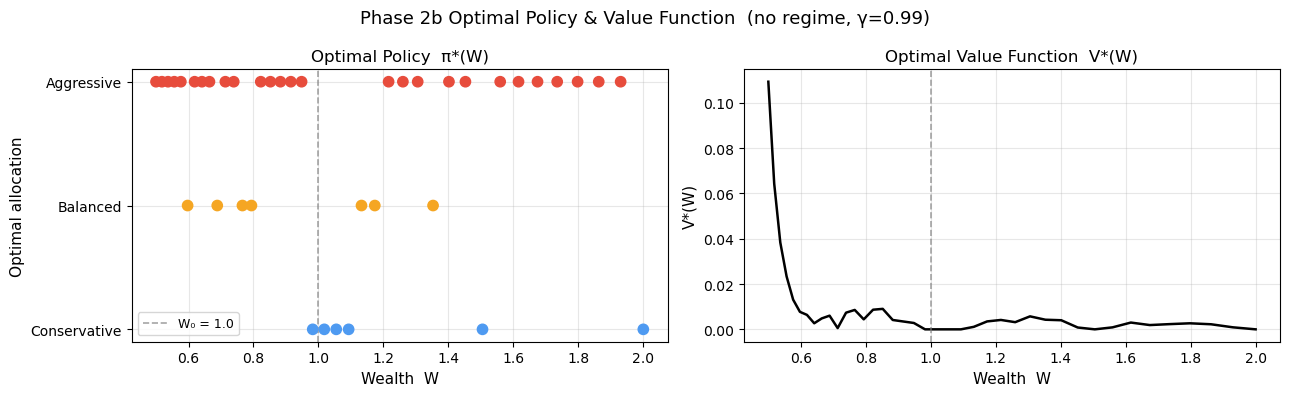

In [23]:
cfg_nr = MDPConfig(
    n_wealth_bins=40,
    wealth_min=0.5,
    wealth_max=2.0,
    initial_wealth=1.0,
    risk_aversion=2.0,
    n_mc_samples=3000,
    use_regime=False,          # no regime
    log_spaced_wealth=True,
    rng_seed=42,
)

mdp_nr, wealth_grid_nr, cfg_nr = build_mdp(params, cfg=cfg_nr)
opt_vf_nr, opt_policy_nr = solve(mdp_nr, gamma=0.99, method='value_iteration')

plot_no_regime(
    opt_vf_nr, opt_policy_nr, wealth_grid_nr,
    cfg=cfg_nr,
    title_suffix='  (no regime, γ=0.99)',
)

---
## 7. Out-of-Sample Backtest (2019–2023)

Apply the regime-aware MDP policy — trained exclusively on **2002–2018** data — to the held-out **2019–2023** test period.

Compare against three fixed-allocation benchmarks (same allocations as the MDP action set):

| Benchmark | Strategy 1 (AL residual) | Strategy 2 (equity carry) |
|---|---|---|
| Conservative | 80 % | 20 % |
| Balanced | 50 % | 50 % |
| Aggressive | 20 % | 80 % |

The MDP policy is **dynamic**: at each day it re-evaluates the current wealth bin (and regime, if applicable) and picks the allocation the value iteration deemed optimal for that state.  The fixed benchmarks hold the same allocation every day regardless of state.


Strategy            Ann. Return    Sharpe    Max DD     Final W
---------------------------------------------------------------
  MDP Policy            +17.60%    +1.012   -20.58%      1.9907
  Conservative           +4.66%    +0.839   -10.50%      1.2134
  Balanced               +9.92%    +0.761   -24.48%      1.4943
  Aggressive            +14.68%    +0.738   -36.69%      1.7887



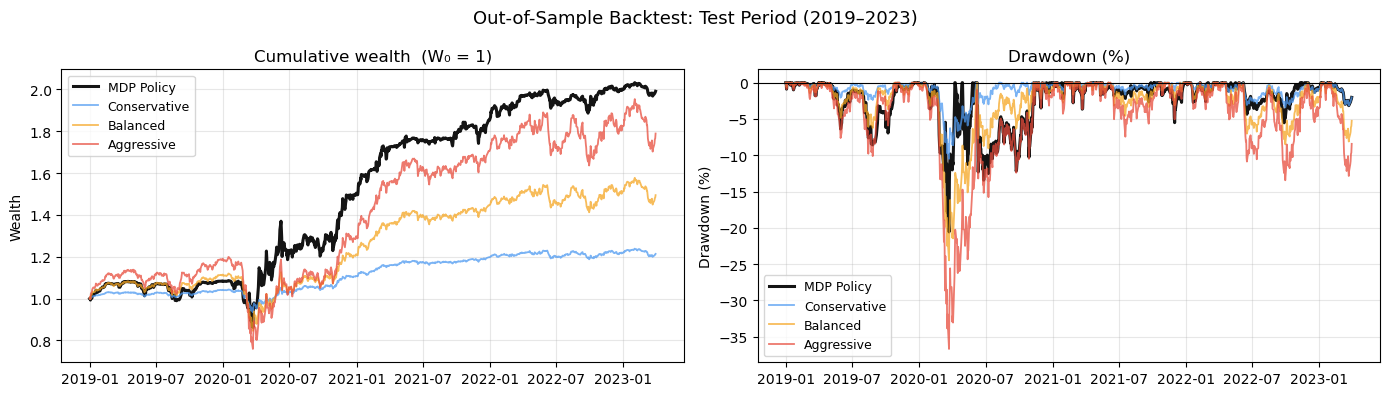

In [24]:
backtest_df = backtest_policy(
    opt_policy=opt_policy,
    test_series=strategy_test,
    wealth_grid=wealth_grid,
    cfg=cfg,
    use_regime=cfg.use_regime,
)

---
## 8. Interpretation

Key questions to answer from the plots:

1. **Wealth threshold:** At what wealth level does the optimal policy switch from
   Conservative (more Strategy 1, Avellaneda–Lee) to Aggressive (more Strategy 2, carry)?
2. **Regime effect:** Does the good regime justify higher carry allocation?
   Conversely, does the bad regime drive the agent to the market-neutral residual strategy?
3. **Value function shape:** Is the CRRA value function concave, as expected? Are there
   kinks corresponding to policy switches?
4. **Strategy 1 vs Strategy 2 calibration:** Compare $(\mu_1, \sigma_1)$ and $(\mu_2, \sigma_2)$.
   Does the carry strategy show a higher mean but also higher vol (consistent with its
   'aggressive' classification)?